# Comparing Two Percent Accuracy Histograms

In [1]:
from pointnet_model import pnet
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

#set batch size
BATCH_SIZE = 32

#specify models: 
#M1:
model1_file_stem = 'models/2023-06-11-19:03:33/weights/cp-038.ckpt' 
data1_file_stem = 'voxel_data/Mg22_size512'

#M2
model2_file_stem = 'models/2023-06-11-19:03:33/weights/cp-032.ckpt' 
data2_file_stem = 'voxel_data/Mg22_size512'

2023-06-13 11:51:45.651713: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Create Percent Accuracy array for Model 1

In [2]:
# build model
model1 = pnet(sem_seg_flag=True, num_points=512, num_classes=27)
model1.load_weights(model1_file_stem)

 # load test data for model1
test_ds = np.load('{}{}'.format(data1_file_stem, 'test.npy'))
test_features = tf.data.Dataset.from_tensor_slices(test_ds[:, :, :3]).batch(BATCH_SIZE)
test_labels = test_ds[:, :, 3]

# make predictions for model1
predicted_probabilities = model1.predict(test_features)
predictions = np.argmax(predicted_probabilities, axis=2)

# set up name and time for model 1
model1_name = model1_file_stem.split("/")[-1] #modified to save model/ckpt name
model1_time =  model1_file_stem.split("/")[-3] #added to save timestamp
    
#create percent accuracy for m1 
percent_accuracy1 = np.mean(test_labels == predictions, axis=1) #along X axis

2023-06-13 11:51:49.969673: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2023-06-13 11:51:50.978919: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [685,512,3]
	 [[{{node Placeholder/_0}}]]


22/22 [==============================] - 5s 212ms/step


## Create Percent Accuracy array for Model 2

In [3]:
#build model
model2 = pnet(sem_seg_flag=True, num_points=512, num_classes=27)
model2.load_weights(model2_file_stem)

# load test data for model2
test_ds2 = np.load('{}{}'.format(data2_file_stem, 'test.npy'))
test_features2 = tf.data.Dataset.from_tensor_slices(test_ds2[:, :, :3]).batch(BATCH_SIZE)
test_labels2 = test_ds2[:, :, 3]

# make predictions for model2
predicted_probabilities2 = model2.predict(test_features2)
predictions2 = np.argmax(predicted_probabilities2, axis=2)

# evaluate results for model 2
model2_name = model2_file_stem.split("/")[-1] #modified to save model/ckpt name
model2_time =  model2_file_stem.split("/")[-3] #added to save timestamp

# create percent accuracy for model 2 
percent_accuracy2 = np.mean(test_labels2 == predictions2, axis=1) #along X axis

2023-06-13 11:51:57.405388: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype double and shape [685,512,3]
	 [[{{node Placeholder/_0}}]]


22/22 [==============================] - 5s 211ms/step


## Plot Overlayed Histograms

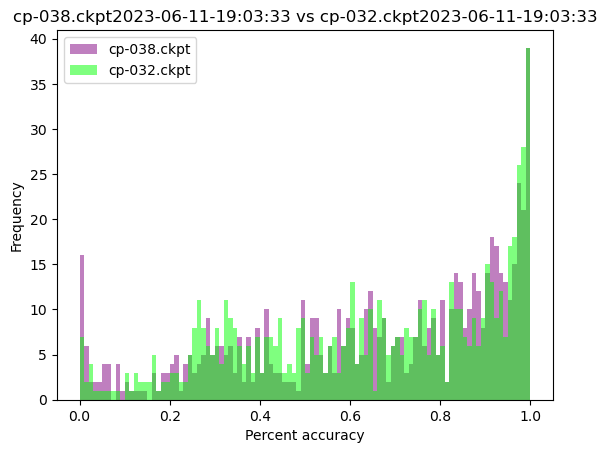

In [4]:
#set title
title = model1_name + model1_time + " vs " + model2_name + model2_time

plt.figure()
plt.hist(percent_accuracy1, bins=100, alpha=0.5, color='purple', label=model1_name)
plt.hist(percent_accuracy2, bins=100, alpha=0.5, color='lime', label=model2_name)
plt.xlabel("Percent accuracy")
plt.ylabel("Frequency")
plt.title(title)
plt.legend(loc = 'upper left')
plt.show()
#plt.savefig("plots/evaluations/comparison_{}.png".format(title)) #to save as png 